In [1]:
import tensorly as tl

tl.get_backend()

'numpy'

In [10]:
from hoda.hoda import HODA
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
import numpy as np
from sklearn.pipeline import Pipeline
from hoda.hoda import BTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import SelectF


hoda_params = dict(
    max_iter=128,
    tol=1e-6,
    shrinkage='lw',
    toeplitz=None,
    obj='tr',
    solver='lanczos',
    taper=False,
    extra_train_info=False,
    verbose=True,
)

bttda_params = dict(
    verbose=True,
    forward=True,
    extra_train_info=False, 
)

clf = Pipeline([
    ('to_numpy', FunctionTransformer(tl.to_numpy)),
    ('scaler', StandardScaler()),
    ('clf', LDA(shrinkage='auto', solver='lsqr'))
])
deltas = [0] + list(np.geomspace(1e-3,1, 5-1))
clf

Pipeline(steps=[('to_numpy',
                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x7f8833787560>)),
                ('scaler', StandardScaler()),
                ('clf',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

In [35]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from sklearn.model_selection import StratifiedKFold, GridSearchCV

sfreq = 48
paradigm = P300(resample=sfreq)
datasets = [BNCI2014_008()]

grid_theta = [0, 0.5, 0.8, 0.9, 0.95, 0.99, 1]
grid_n_blocks = list(range(1,5+1))

cv = StratifiedKFold(n_splits=5)

In [36]:
import pandas as pd
import tensorly as tl
from sklearn.metrics import roc_auc_score
from mne.decoding import Scaler

results = []

for dataset in datasets:
    for subject in dataset.subject_list[:1]:
        data, labels, meta = paradigm.get_data(dataset=dataset, subjects=[subject])
        X = tl.tensor(data)
        y = labels
        for fold, (train_idc, test_idc) in enumerate(cv.split(X, y)):
            print(f'fold={fold}')
            scaler = Scaler(scalings='mean', with_mean=True)
            Xs = scaler.fit(X[train_idc])
            Xs = scaler.transform(X)
            
            for theta in grid_theta:
                print(f'theta={theta}')
                hoda_params['theta'] = theta
                bttda = BTTDA(
                    ranks=[None]*max(grid_n_blocks),
                    hoda_params=hoda_params,
                    **bttda_params
                )            
                bttda.fit(Xs[train_idc], y[train_idc])
            
                for n_blocks in grid_n_blocks:
                    print(f'n_blocks={n_blocks}')   
                    Xt = bttda.transform(Xs, n_blocks=n_blocks)
                    X_rec = bttda.inv_transform(Xt, n_blocks=n_blocks)
                    
                    clf.fit(Xt[train_idc], y[train_idc])
                    y_proba_pred = clf.predict_proba(Xt)
                    res = dict(
                        subject = subject,
                        dataset = dataset.code,
                        fold = fold,
                        theta=theta,
                        n_blocks=n_blocks,
                        train_roc_auc = roc_auc_score(y[train_idc], y_proba_pred[train_idc,1]),
                        test_roc_auc = roc_auc_score(y[test_idc], y_proba_pred[test_idc,1]),
                        train_mse = tl.metrics.regression.MSE(X[train_idc], X_rec[train_idc]),
                        test_mse = tl.metrics.regression.MSE(X[test_idc], X_rec[test_idc]),          
                    )
                    results.append(res)

results = pd.DataFrame(results)

/usr/local/share/venv/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>



fold=0
theta=0
Fitting block 1/5...


Forward model :  15%|███████████████▍                                                                                        | 19/128 [00:00<00:01, 69.86it/s]


Fitting block 2/5...


Forward model :   5%|████▉                                                                                                    | 6/128 [00:00<00:02, 59.16it/s]


...

Fitting block 4/5...


Forward model :   1%|▊                                                                                                        | 1/128 [00:00<00:13,  9.13it/s]


Fitting block 5/5...


Forward model :   1%|▊                                                                                                        | 1/128 [00:00<00:16,  7.88it/s]


n_blocks=1
n_blocks=2
n_blocks=3
n_blocks=4
n_blocks=5


In [37]:
results

,subject,dataset,fold,theta,n_blocks,train_roc_auc,test_roc_auc,train_mse,test_mse
0,1,BNCI2014-008,0,0.0,1,0.831027,0.804684,99.429307,136.043399
1,1,BNCI2014-008,0,0.0,2,0.830908,0.802490,99.413425,136.032988
2,1,BNCI2014-008,0,0.0,3,0.857144,0.818337,99.395382,136.009728
3,1,BNCI2014-008,0,0.0,4,0.872575,0.810929,99.381031,135.995572
4,1,BNCI2014-008,0,0.0,5,0.872474,0.811388,99.375881,135.992213
...,...,...,...,...,...,...,...,...,...
170,1,BNCI2014-008,4,1.0,1,0.894600,0.852316,89.169690,81.108592
171,1,BNCI2014-008,4,1.0,2,0.920508,0.829102,89.169690,81.108592
172,1,BNCI2014-008,4,1.0,3,0.941545,0.813143,89.169690,81.108592
173,1,BNCI2014-008,4,1.0,4,0.955575,0.791306,89.169690,81.108592


<Axes: xlabel='n_blocks', ylabel='test_roc_auc'>

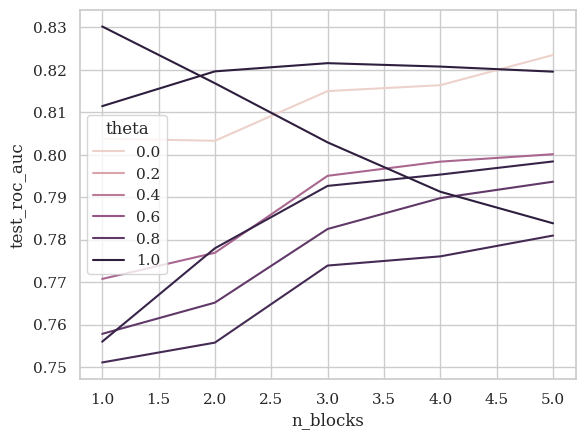

In [38]:
import seaborn as sns
sns.lineplot(data=results, x='n_blocks', y='test_roc_auc', hue='theta', errorbar=None)

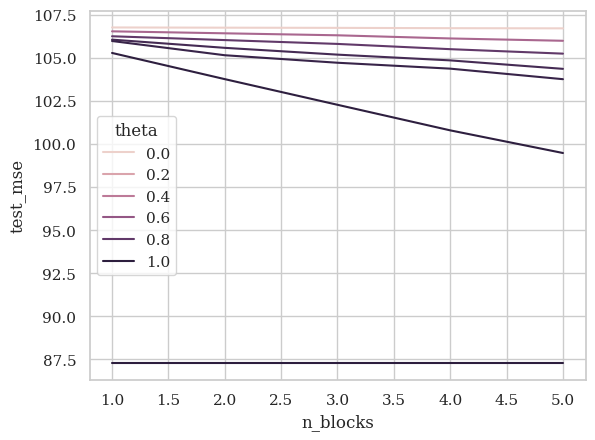

In [41]:
import seaborn as sns
ax = sns.lineplot(data=results, x='n_blocks', y='test_mse', hue='theta', errorbar=None)